In [102]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import Birch
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import  StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV,train_test_split
from xgboost import XGBRegressor
import warnings
import time


In [5]:
def modelBuilder(n=2):
  """
  Returns a dictionary of clustering models instances with speficied number of clusters.
  n: number of clusters
  """
  models = {}

  models['K-Means'] = KMeans(n_clusters=n,random_state=42)
  models['BIRCH'] = Birch(n_clusters=n)
  models['Agglomerative'] = AgglomerativeClustering(n_clusters=n)
  models['Mini-Batch K-Means'] = MiniBatchKMeans(n_clusters=n,random_state=42)

  return models

In [6]:
dataset_train=pd.read_csv('childcare_costs_cleaned.csv')

In [7]:
dataset_train.head()

,state_name,county_name,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,memr_20to64,unr_16,funr_16,...,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa
0,Alabama,Autauga County,55.5,49.4,62.2,69.8,63.5,76.4,2.8,2.3,...,21.9,15.7,29.0,9.5,16.5,1.5,15.5,23.0,6.8,110.0
1,Alabama,Baldwin County,56.8,52.6,61.3,72.9,67.7,78.5,3.7,4.5,...,23.6,16.1,31.8,9.5,17.1,1.3,13.0,20.2,5.2,110.0
2,Alabama,Barbour County,41.5,44.1,39.2,52.1,58.1,47.4,8.6,11.5,...,19.9,9.7,30.3,12.2,23.1,1.0,21.6,28.4,14.7,99.0
3,Alabama,Bibb County,44.9,43.7,45.8,54.0,55.9,52.6,9.7,10.2,...,21.5,15.5,29.3,16.6,28.7,1.1,23.1,32.6,11.0,120.0
4,Alabama,Blount County,51.7,46.2,57.3,65.6,58.7,72.2,6.0,5.6,...,21.6,13.3,31.7,15.3,27.2,0.6,21.1,28.7,11.7,123.0


In [8]:
#X=df.drop(columns='mcsa',axis=1)
#y=df['mcsa']

In [9]:
num_features = dataset_train.select_dtypes(exclude="object").columns

In [10]:
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    [
         ("StandardScaler", numeric_transformer, num_features)       
    ]
)

In [11]:
X=preprocessor.fit_transform(dataset_train)




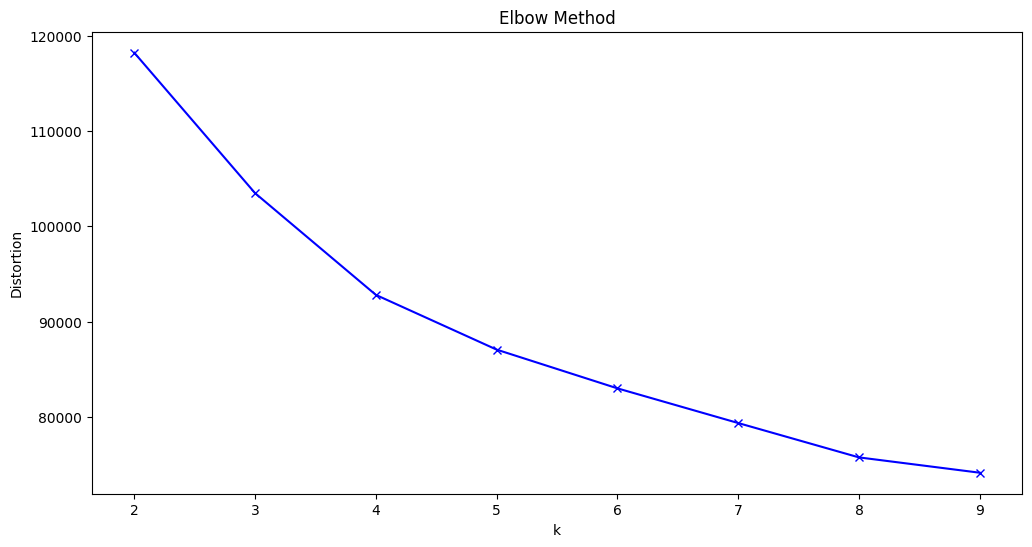

In [12]:
distortions = []
clusters = range(2, 10)
for k in clusters:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)
plt.figure(figsize=(12,6))
plt.plot(clusters, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('Elbow Method')
plt.show()

In [13]:
clusters = range(2,10)

for k in clusters:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    labels = kmeans.predict(X)
    silhouette_avg = silhouette_score(X, labels)
    print('n_clusters = {}; avg. silhouette_score = {:.5f}'.format(k, silhouette_avg))

n_clusters = 2; avg. silhouette_score = 0.18671
n_clusters = 3; avg. silhouette_score = 0.20492
n_clusters = 4; avg. silhouette_score = 0.17777
n_clusters = 5; avg. silhouette_score = 0.17008
n_clusters = 6; avg. silhouette_score = 0.12230
n_clusters = 7; avg. silhouette_score = 0.12623
n_clusters = 8; avg. silhouette_score = 0.09947
n_clusters = 9; avg. silhouette_score = 0.09938


In [14]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
labels = kmeans.predict(X)

In [15]:
dataset_clustered = pd.concat([
    pd.DataFrame(X, columns=dataset_train.drop(['county_name', 'state_name'], axis=1).columns), 
    pd.DataFrame(labels, columns=['cluster']),  
    dataset_train[['county_name', 'state_name']].reset_index(drop=True,inplace=True) 
], axis=1)

In [16]:
dataset_clustered.columns

Index(['emr_16', 'femr_16', 'memr_16', 'emr_20to64', 'femr_20to64',
       'memr_20to64', 'unr_16', 'funr_16', 'munr_16', 'unr_20to64',
       'funr_20to64', 'munr_20to64', 'flfpr_20to64', 'flfpr_20to64_under6',
       'flfpr_20to64_6to17', 'flfpr_20to64_under6_6to17', 'mlfpr_20to64',
       'pr_f', 'pr_p', 'mfi_2022', 'mhi_2022', 'me_2022', 'fme_2022',
       'mme_2022', 'totalpop', 'onerace', 'onerace_w', 'onerace_b',
       'onerace_i', 'onerace_a', 'onerace_h', 'onerace_other', 'tworaces',
       'hispanic', 'households', 'h_under6_bothwork', 'h_under6_fwork',
       'h_under6_mwork', 'h_under6_singlem', 'h_6to17_bothwork',
       'h_6to17_fwork', 'h_6to17_mwork', 'h_6to17_singlem', 'emp_m', 'memp_m',
       'femp_m', 'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'cluster'],
      dtype='object')

In [17]:
dataset_clustered.groupby('cluster').mean(['mcsa'])

,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,memr_20to64,unr_16,funr_16,munr_16,unr_20to64,...,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.897442,-0.839624,-0.847604,-0.905940,-0.850446,-0.828235,0.615905,0.556947,0.567980,0.619999,...,0.024095,-0.166013,0.137103,0.164409,0.227694,-0.031807,0.337876,0.369972,0.212272,-0.445591
1,0.624198,0.583984,0.589534,0.630109,0.591512,0.576063,-0.428381,-0.387374,-0.395048,-0.431228,...,-0.016759,0.115467,-0.095360,-0.114352,-0.158368,0.022123,-0.235003,-0.257327,-0.147642,0.309922


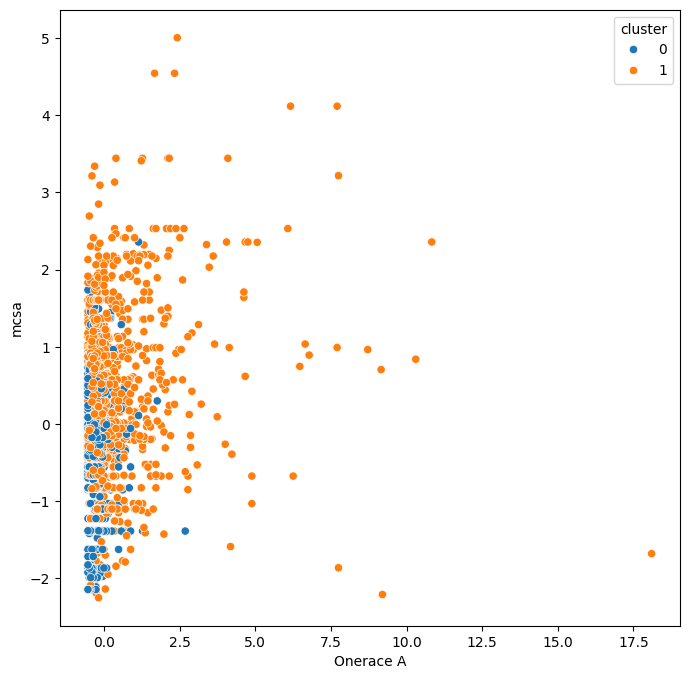

In [18]:
col='onerace_a'
plt.figure(figsize=(8,8))
sns.scatterplot(x=col , y='mcsa', data=dataset_clustered, hue='cluster')
plt.xlabel(col.title().replace('_', ' ')) 
plt.ylabel('mcsa') 
plt.show()


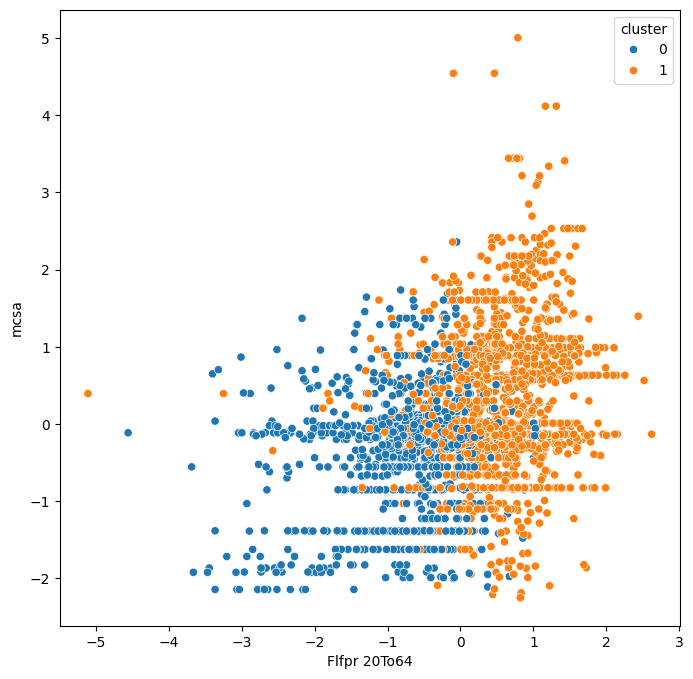

In [19]:
col='flfpr_20to64'
plt.figure(figsize=(8,8))
sns.scatterplot(x=col , y='mcsa', data=dataset_clustered, hue='cluster')
plt.xlabel(col.title().replace('_', ' ')) 
plt.ylabel('mcsa') 
plt.show()

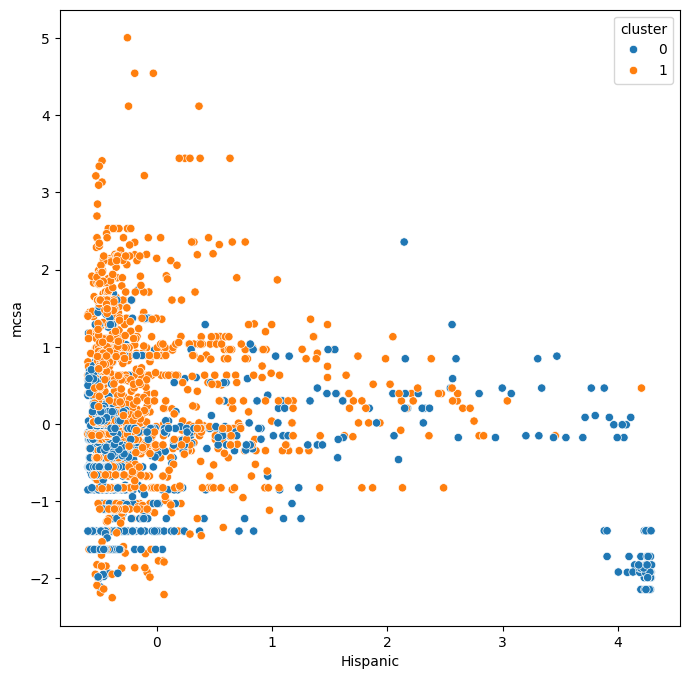

In [20]:
col='hispanic'
plt.figure(figsize=(8,8))
sns.scatterplot(x=col , y='mcsa', data=dataset_clustered, hue='cluster')
plt.xlabel(col.title().replace('_', ' ')) 
plt.ylabel('mcsa') 
plt.show()

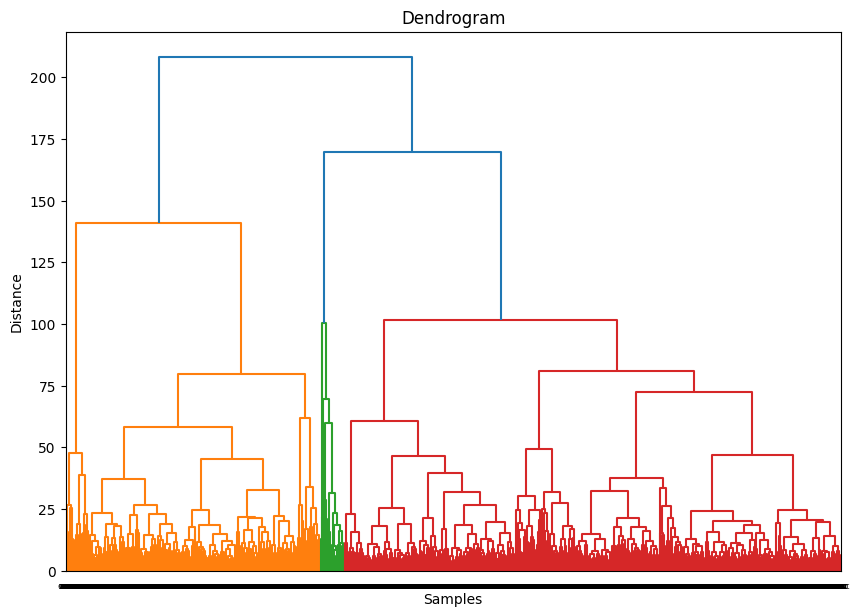

In [21]:
# Perform hierarchical clustering
linkage_matrix = linkage(X, method='ward')  # 'ward', 'complete', 'average', 'single'

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, labels=dataset_train.index, leaf_rotation=180)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [22]:
agg_clustering = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels = agg_clustering.fit_predict(X)

In [23]:
dataset_clustered_agg = pd.concat([
    pd.DataFrame(X, columns=dataset_train.drop(['county_name', 'state_name'], axis=1).columns), 
    pd.DataFrame(labels, columns=['cluster']),  
    dataset_train[['county_name', 'state_name']]  
], axis=1)

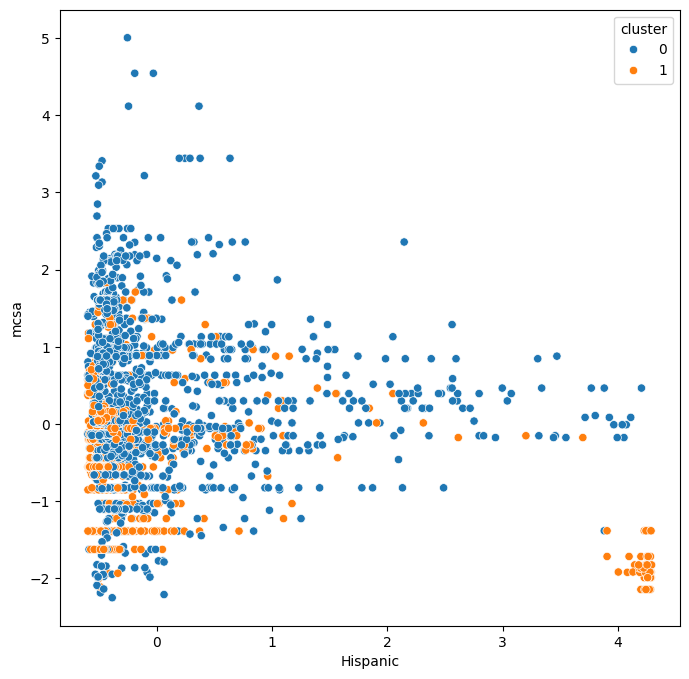

In [24]:
col='hispanic'
plt.figure(figsize=(8,8))
sns.scatterplot(x=col , y='mcsa', data=dataset_clustered_agg, hue='cluster')
plt.xlabel(col.title().replace('_', ' ')) 
plt.ylabel('mcsa') 
plt.show()

In [25]:
dataset_clustered_agg.groupby('cluster').mean(['mcsa'])

,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,memr_20to64,unr_16,funr_16,munr_16,unr_20to64,...,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.508126,0.469272,0.483278,0.506892,0.464990,0.470266,-0.350085,-0.330108,-0.313244,-0.350666,...,-0.020698,0.077327,-0.065294,-0.038179,-0.075914,0.038007,-0.197253,-0.202697,-0.158457,0.246012
1,-1.032111,-0.953191,-0.981639,-1.029605,-0.944492,-0.955209,0.711097,0.670518,0.636265,0.712276,...,0.042041,-0.157068,0.132626,0.077549,0.154197,-0.077201,0.400662,0.411720,0.321860,-0.499703


In [26]:
dataset_clustered.groupby("cluster").mean('mcsa').T

cluster,0,1
emr_16,-0.897442,0.624198
femr_16,-0.839624,0.583984
memr_16,-0.847604,0.589534
emr_20to64,-0.905940,0.630109
femr_20to64,-0.850446,0.591512
memr_20to64,-0.828235,0.576063
unr_16,0.615905,-0.428381
funr_16,0.556947,-0.387374
munr_16,0.567980,-0.395048
unr_20to64,0.619999,-0.431228


In [27]:
dataset_clustered_agg.groupby("cluster").mean('mcsa').T

cluster,0,1
emr_16,0.508126,-1.032111
femr_16,0.469272,-0.953191
memr_16,0.483278,-0.981639
emr_20to64,0.506892,-1.029605
femr_20to64,0.464990,-0.944492
memr_20to64,0.470266,-0.955209
unr_16,-0.350085,0.711097
funr_16,-0.330108,0.670518
munr_16,-0.313244,0.636265
unr_20to64,-0.350666,0.712276


In [28]:
birch = Birch(branching_factor=50, n_clusters=3, threshold=1.5)
birch.fit(X)

Birch(threshold=1.5)

In [29]:
labels_birch = birch.predict(X)

In [30]:
dataset_clustered_birch = pd.concat([
    pd.DataFrame(X, columns=dataset_train.drop(['county_name', 'state_name'], axis=1).columns), 
    pd.DataFrame(labels_birch, columns=['cluster']),  
    dataset_train[['county_name', 'state_name']]  
], axis=1)

In [31]:
dataset_clustered_birch.groupby("cluster").mean('mcsa').T

cluster,0,1,2
emr_16,-0.797403,0.981572,0.538741
femr_16,-0.771676,0.966525,0.519112
memr_16,-0.733304,0.908472,0.494650
emr_20to64,-0.792535,0.713786,0.570841
femr_20to64,-0.774664,0.672938,0.561315
memr_20to64,-0.703601,0.660620,0.503144
unr_16,0.523081,-0.127706,-0.423181
funr_16,0.491861,-0.071574,-0.404481
munr_16,0.467464,-0.150288,-0.373298
unr_20to64,0.526956,-0.144316,-0.424198


In [32]:
X_train=dataset_train.drop(columns='mcsa',axis=1)

y_train=dataset_train['mcsa']


In [33]:
X_train.shape

(2428, 60)

In [34]:
num_features_train=X_train.select_dtypes(exclude="object")

In [35]:
scale=StandardScaler()
X_train=scale.fit_transform(num_features_train)



In [36]:
# Initialize a dictionary to store results
results = {
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}
runtime = {  # Dictionary to store runtimes
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}

clusters = list(range(2, 10))

# Iterate over the number of clusters
for c in clusters:
    print('\nNumber of clusters = {}'.format(c))
    models = modelBuilder(n=c)
    
    # Iterate over the models
    for m in models.keys():
        model = models[m]
        
        # Measure time
        start_time = time.time()
        model.fit(X_train)
        end_time = time.time()
        
        # Compute silhouette score
        sc = silhouette_score(X_train, model.labels_)
        elapsed_time = end_time - start_time
        
        # Store results
        print('Silhouette score for {} using {} clusters = {:.4f}'.format(m, c, sc))
        print('Runtime for {} using {} clusters = {:.4f} seconds'.format(m, c, elapsed_time))
        results[m][c] = sc
        runtime[m][c] = elapsed_time



Number of clusters = 2
Silhouette score for K-Means using 2 clusters = 0.1906
Runtime for K-Means using 2 clusters = 0.0208 seconds
Silhouette score for BIRCH using 2 clusters = 0.1972
Runtime for BIRCH using 2 clusters = 0.8397 seconds
Silhouette score for Agglomerative using 2 clusters = 0.1972
Runtime for Agglomerative using 2 clusters = 0.3066 seconds
Silhouette score for Mini-Batch K-Means using 2 clusters = 0.1746
Runtime for Mini-Batch K-Means using 2 clusters = 0.1697 seconds

Number of clusters = 3
Silhouette score for K-Means using 3 clusters = 0.2087
Runtime for K-Means using 3 clusters = 0.0190 seconds
Silhouette score for BIRCH using 3 clusters = 0.2059
Runtime for BIRCH using 3 clusters = 0.7211 seconds
Silhouette score for Agglomerative using 3 clusters = 0.2059
Runtime for Agglomerative using 3 clusters = 0.4448 seconds
Silhouette score for Mini-Batch K-Means using 3 clusters = 0.1891
Runtime for Mini-Batch K-Means using 3 clusters = 0.2306 seconds

Number of clusters 

In [37]:
pd.set_option('display.float_format', '{:.5f}'.format)
results_df = pd.DataFrame(results)
runtime_df = pd.DataFrame(runtime)
print(results_df)
print (runtime_df)

   K-Means   BIRCH  Agglomerative  Mini-Batch K-Means
2  0.19064 0.19716        0.19716             0.17457
3  0.20870 0.20594        0.20594             0.18913
4  0.17488 0.19028        0.19028             0.13630
5  0.11690 0.19180        0.19180             0.14182
6  0.12487 0.07727        0.07727             0.09502
7  0.10961 0.05375        0.05375             0.08816
8  0.11344 0.06111        0.06111             0.07195
9  0.09846 0.06356        0.06356             0.08286
   K-Means   BIRCH  Agglomerative  Mini-Batch K-Means
2  0.02080 0.83970        0.30660             0.16970
3  0.01904 0.72112        0.44476             0.23056
4  0.02164 0.81623        0.34910             0.18734
5  0.02407 0.77496        0.37521             0.18935
6  0.02611 0.75400        0.38965             0.18142
7  0.02299 0.82120        0.35429             0.18644
8  0.02552 0.70127        0.34320             0.18690
9  0.02969 0.70135        0.32251             0.18327


In [38]:
print(results_df.unstack().max())
print(runtime_df.unstack().min())

0.20869935381113225
0.01903676986694336


In [39]:
from sklearn.metrics import calinski_harabasz_score
# Initialize a dictionary to store results
results = {
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}
runtime = {  # Dictionary to store runtimes
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}

clusters = list(range(2, 10))

# Iterate over the number of clusters
for c in clusters:
    print('\nNumber of clusters = {}'.format(c))
    models = modelBuilder(n=c)
    
    # Iterate over the models
    for m in models.keys():
        model = models[m]
        
        # Measure time
        start_time = time.time()
        model.fit(X_train)
        end_time = time.time()
        
        # Compute silhouette score
        sc = calinski_harabasz_score(X_train, model.labels_)
        elapsed_time = end_time - start_time
        
        # Store results
        print('calinski_harabasz_score for {} using {} clusters = {:.4f}'.format(m, c, sc))
        print('Runtime for {} using {} clusters = {:.4f} seconds'.format(m, c, elapsed_time))
        results[m][c] = sc
        runtime[m][c] = elapsed_time


Number of clusters = 2
calinski_harabasz_score for K-Means using 2 clusters = 516.8732
Runtime for K-Means using 2 clusters = 0.0377 seconds
calinski_harabasz_score for BIRCH using 2 clusters = 452.1373
Runtime for BIRCH using 2 clusters = 0.7521 seconds
calinski_harabasz_score for Agglomerative using 2 clusters = 452.1373
Runtime for Agglomerative using 2 clusters = 0.2917 seconds
calinski_harabasz_score for Mini-Batch K-Means using 2 clusters = 505.3192
Runtime for Mini-Batch K-Means using 2 clusters = 0.1370 seconds

Number of clusters = 3
calinski_harabasz_score for K-Means using 3 clusters = 471.2578
Runtime for K-Means using 3 clusters = 0.0190 seconds
calinski_harabasz_score for BIRCH using 3 clusters = 417.1204
Runtime for BIRCH using 3 clusters = 0.7059 seconds
calinski_harabasz_score for Agglomerative using 3 clusters = 417.1204
Runtime for Agglomerative using 3 clusters = 0.3190 seconds
calinski_harabasz_score for Mini-Batch K-Means using 3 clusters = 436.8301
Runtime for M

In [40]:
pd.set_option('display.float_format', '{:.5f}'.format)
results_df = pd.DataFrame(results)
runtime_df = pd.DataFrame(runtime)
print(results_df)
print (runtime_df)

    K-Means     BIRCH  Agglomerative  Mini-Batch K-Means
2 516.87315 452.13734      452.13734           505.31921
3 471.25777 417.12044      417.12044           436.83010
4 444.33767 384.70375      384.70375           386.92399
5 383.50536 343.39771      343.39771           391.57178
6 369.32300 315.51647      315.51647           359.78477
7 337.88918 286.37869      286.37869           330.83424
8 312.13911 266.59376      266.59376           284.24259
9 293.97769 249.69526      249.69526           260.36341
   K-Means   BIRCH  Agglomerative  Mini-Batch K-Means
2  0.03773 0.75208        0.29174             0.13700
3  0.01897 0.70587        0.31903             0.15539
4  0.02024 0.71135        0.38648             0.33015
5  0.02729 0.74632        0.33027             0.20850
6  0.02679 0.74675        0.31268             0.17100
7  0.02546 0.70766        0.29236             0.17646
8  0.02761 0.77179        0.30216             0.17888
9  0.03133 0.69621        0.31180             0.17663


In [41]:
print(results_df.unstack().max())
print(runtime_df.unstack().min())

516.8731541633821
0.01896953582763672


In [42]:
from sklearn.metrics import davies_bouldin_score
# Initialize a dictionary to store results
results = {
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}
runtime = {  # Dictionary to store runtimes
    'K-Means': {},
    'BIRCH': {},
    'Agglomerative': {},
    'Mini-Batch K-Means': {}
}

clusters = list(range(2, 10))

# Iterate over the number of clusters
for c in clusters:
    print('\nNumber of clusters = {}'.format(c))
    models = modelBuilder(n=c)
    
    # Iterate over the models
    for m in models.keys():
        model = models[m]
        
        # Measure time
        start_time = time.time()
        model.fit(X_train)
        end_time = time.time()
        
        # Compute silhouette score
        sc = davies_bouldin_score(X_train, model.labels_)
        elapsed_time = end_time - start_time
        
        # Store results
        print('davies_bouldin_score for {} using {} clusters = {:.4f}'.format(m, c, sc))
        print('Runtime for {} using {} clusters = {:.4f} seconds'.format(m, c, elapsed_time))
        results[m][c] = sc
        runtime[m][c] = elapsed_time


Number of clusters = 2
davies_bouldin_score for K-Means using 2 clusters = 1.8481
Runtime for K-Means using 2 clusters = 0.0202 seconds
davies_bouldin_score for BIRCH using 2 clusters = 1.9311
Runtime for BIRCH using 2 clusters = 0.6752 seconds
davies_bouldin_score for Agglomerative using 2 clusters = 1.9311
Runtime for Agglomerative using 2 clusters = 0.2990 seconds
davies_bouldin_score for Mini-Batch K-Means using 2 clusters = 1.8696
Runtime for Mini-Batch K-Means using 2 clusters = 0.1348 seconds

Number of clusters = 3
davies_bouldin_score for K-Means using 3 clusters = 1.5535
Runtime for K-Means using 3 clusters = 0.0239 seconds
davies_bouldin_score for BIRCH using 3 clusters = 1.6497
Runtime for BIRCH using 3 clusters = 0.6979 seconds
davies_bouldin_score for Agglomerative using 3 clusters = 1.6497
Runtime for Agglomerative using 3 clusters = 0.2893 seconds
davies_bouldin_score for Mini-Batch K-Means using 3 clusters = 1.7374
Runtime for Mini-Batch K-Means using 3 clusters = 0.1

In [43]:
pd.set_option('display.float_format', '{:.5f}'.format)
results_df = pd.DataFrame(results)
runtime_df = pd.DataFrame(runtime)
print(results_df)
print (runtime_df)

   K-Means   BIRCH  Agglomerative  Mini-Batch K-Means
2  1.84811 1.93112        1.93112             1.86958
3  1.55350 1.64972        1.64972             1.73744
4  1.57651 1.58001        1.58001             1.65404
5  1.86997 1.32986        1.32986             1.61765
6  1.73803 1.84297        1.84297             1.78779
7  1.81985 1.92920        1.92920             1.83301
8  1.84175 1.82309        1.82309             2.00328
9  1.75166 1.67629        1.67629             2.00578
   K-Means   BIRCH  Agglomerative  Mini-Batch K-Means
2  0.02016 0.67521        0.29896             0.13483
3  0.02390 0.69792        0.28926             0.14395
4  0.01986 0.67031        0.29337             0.18492
5  0.02723 0.69202        0.29935             0.18893
6  0.03517 0.71931        0.31638             0.19416
7  0.03165 0.81606        0.33073             0.18442
8  0.02723 0.75515        0.33934             0.17591
9  0.02589 0.73481        0.33460             0.19456


In [44]:
print(results_df.unstack().min())
print(runtime_df.unstack().min())

1.3298554814070134
0.019859790802001953


In [45]:
# 3 clusters- cluster 3 had just 15 observations(really less training data)- we decide to go with two clusters
# # Algorithm- K means

In [46]:
kmeans = KMeans(n_clusters=2,random_state=42)
kmeans.fit(X_train)
labels = kmeans.predict(X_train)

In [47]:
dataset_clustered_train = pd.concat([
    pd.DataFrame(X_train, columns=dataset_train.drop(['county_name','state_name','mcsa'], axis=1).columns), 
    pd.DataFrame(labels, columns=['cluster']),  dataset_train[['county_name','mcsa']].reset_index(drop=True)
    
], axis=1)



In [48]:
cluster_1=dataset_clustered_train[dataset_clustered_train['cluster']==0]
cluster_2=dataset_clustered_train[dataset_clustered_train['cluster']==1]


In [49]:
cluster_1.shape


(1447, 61)

In [50]:
# now i NEED train test values for each cluster to run my model

X_c1=cluster_1.drop(columns=['mcsa','county_name'],axis=1)
y_c1=cluster_1['mcsa']

X_c2=cluster_2.drop(columns=['mcsa','county_name'],axis=1)
y_c2=cluster_2['mcsa']

In [51]:

X_trainc1,X_testc1,y_trainc1,y_testc1=train_test_split(X_c1,y_c1,test_size=0.2,random_state=42)
X_trainc2,X_testc2,y_trainc2,y_testc2=train_test_split(X_c2,y_c2,test_size=0.2,random_state=42)

Hyperparamter Tuning (RF)

In [ ]:

param_distributions = {
    "max_features": [None,'sqrt','log2'],
    "max_leaf_nodes": [10, 100, 1000, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid=param_distributions
                           ,cv=10, scoring="neg_root_mean_squared_error",
                           verbose=1,n_jobs=-1,
                           error_score='raise')
grid_search.fit(X_trainc1,y_trainc1)

Fitting 10 folds for each of 84 candidates, totalling 840 fits


GridSearchCV(cv=10, error_score='raise',
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 100, 1000, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [70]:
grid_search.best_estimator_

RandomForestRegressor(max_features='sqrt', random_state=42)

In [67]:
param_distributions = {
    "max_features": [None,'sqrt','log2'],
    "max_leaf_nodes": [10, 100, 1000, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid=param_distributions
                           ,cv=10, scoring="neg_root_mean_squared_error",
                           verbose=1,n_jobs=-1,
                           error_score='raise')
grid_search.fit(X_trainc2,y_trainc2)

Fitting 10 folds for each of 84 candidates, totalling 840 fits


GridSearchCV(cv=10, error_score='raise',
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [10, 100, 1000, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [68]:
grid_search.best_estimator_

RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, random_state=42)

Hyperparamter Tuning (Boosting techniques)

In [97]:
def evaluate_model(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
models = {
    "Random Forest Regressor for Cluster 1": RandomForestRegressor(max_features='sqrt',random_state=42)
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_trainc1, y_trainc1) # Train model
 

    # Make predictions
    y_train_predc1 = model.predict(X_trainc1)
    y_test_predc1 = model.predict(X_testc1)
    


    
    # Evaluate Train and Test dataset
    model_train_rmse_c1 = evaluate_model(y_trainc1, y_train_predc1)

    model_test_rmse_c1= evaluate_model(y_testc1, y_test_predc1)



    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse_c1))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse_c1))
    
    print('='*35)
    print('\n') 
#delete later

Random Forest Regressor for Cluster 1
Model performance for Training set
- Root Mean Squared Error: 13.3717
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 37.4703




In [100]:
#delete later
models = {
    "Random Forest Regressor for Cluster 2": RandomForestRegressor(max_features='sqrt',min_samples_leaf=2,random_state=42)
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_trainc2, y_trainc2) # Train model
 

    # Make predictions
    y_train_predc2 = model.predict(X_trainc2)
    y_test_predc2 = model.predict(X_testc2)
    


    
    # Evaluate Train and Test dataset
    model_train_rmse_c2 = evaluate_model(y_trainc2, y_train_predc2)

    model_test_rmse_c2= evaluate_model(y_testc2, y_test_predc2)



    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse_c2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse_c2))
    
    print('='*35)
    print('\n') 

Random Forest Regressor for Cluster 2
Model performance for Training set
- Root Mean Squared Error: 12.2582
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 27.2584




In [103]:
# Define the models for both clusters
models = {
    "Random Forest Regressor for Cluster 1": RandomForestRegressor(max_features='sqrt', random_state=42),
    "Random Forest Regressor for Cluster 2": RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, random_state=42)
}

# Define datasets for each cluster
datasets = {
    "Cluster 1": {"X_train": X_trainc1, "X_test": X_testc1, "y_train": y_trainc1, "y_test": y_testc1},
    "Cluster 2": {"X_train": X_trainc2, "X_test": X_testc2, "y_train": y_trainc2, "y_test": y_testc2}
}

# Initialize lists to store results
model_list = []
rmse_train_list = []
rmse_test_list = []
feature_importances = {}  # Dictionary to store feature importances for each cluster

# Iterate through the models and corresponding datasets
for model_name, model in models.items():
    # Determine the cluster
    cluster = "Cluster 1" if "Cluster 1" in model_name else "Cluster 2"
    data = datasets[cluster]
    
    # Train the model
    model.fit(data["X_train"], data["y_train"])
    
    # Make predictions
    y_train_pred = model.predict(data["X_train"])
    y_test_pred = model.predict(data["X_test"])
    
    # Evaluate the model
    rmse_train = evaluate_model(data["y_train"], y_train_pred)
    rmse_test = evaluate_model(data["y_test"], y_test_pred)
    
    # Store results
    model_list.append(model_name)
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)
    
    # Get feature importances
    feature_importances[cluster] = model.feature_importances_
    feature_names = data["X_train"].columns  # Assuming X_train is a DataFrame
    
    # Print results
    print(model_name)
    print(f"Model performance for Training set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_train:.4f}")
    print("----------------------------------")
    print(f"Model performance for Test set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_test:.4f}")
    print("----------------------------------")
    print("Top Feature Importances:")
    important_features = sorted(zip(feature_names, feature_importances[cluster]), key=lambda x: x[1], reverse=True)
    for feature, importance in important_features[:10]:  # Display top 10 features
        print(f"{feature}: {importance:.4f}")
    print("=" * 35)
    print('\n')


Random Forest Regressor for Cluster 1
Model performance for Training set (Cluster: Cluster 1)
- Root Mean Squared Error: 13.3717
----------------------------------
Model performance for Test set (Cluster: Cluster 1)
- Root Mean Squared Error: 37.4703
----------------------------------
Top Feature Importances:
mfi_2022: 0.0443
fme_2022: 0.0360
memp_p: 0.0340
emp_p: 0.0283
femp_m: 0.0255
emp_m: 0.0253
me_2022: 0.0245
onerace_b: 0.0231
pr_f: 0.0216
mhi_2022: 0.0216


Random Forest Regressor for Cluster 2
Model performance for Training set (Cluster: Cluster 2)
- Root Mean Squared Error: 12.2582
----------------------------------
Model performance for Test set (Cluster: Cluster 2)
- Root Mean Squared Error: 27.2584
----------------------------------
Top Feature Importances:
mfi_2022: 0.0661
hispanic: 0.0565
mme_2022: 0.0444
pr_f: 0.0434
femp_p: 0.0412
mhi_2022: 0.0405
emp_p: 0.0288
memp_p: 0.0252
me_2022: 0.0252
onerace_b: 0.0245




In [ ]:
#Plot Feature Importance

In [104]:
models = {
    "XG Boost Regressor for Cluster 1": XGBRegressor(),
    "XG Boost Regressor for Cluster 2": XGBRegressor()
}

# Define datasets for each cluster
datasets = {
    "Cluster 1": {"X_train": X_trainc1, "X_test": X_testc1, "y_train": y_trainc1, "y_test": y_testc1},
    "Cluster 2": {"X_train": X_trainc2, "X_test": X_testc2, "y_train": y_trainc2, "y_test": y_testc2}
}

# Initialize lists to store results
model_list = []
rmse_train_list = []
rmse_test_list = []
feature_importances = {}  # Dictionary to store feature importances for each cluster

# Iterate through the models and corresponding datasets
for model_name, model in models.items():
    # Determine the cluster
    cluster = "Cluster 1" if "Cluster 1" in model_name else "Cluster 2"
    data = datasets[cluster]
    
    # Train the model
    model.fit(data["X_train"], data["y_train"])
    
    # Make predictions
    y_train_pred = model.predict(data["X_train"])
    y_test_pred = model.predict(data["X_test"])
    
    # Evaluate the model
    rmse_train = evaluate_model(data["y_train"], y_train_pred)
    rmse_test = evaluate_model(data["y_test"], y_test_pred)
    
    # Store results
    model_list.append(model_name)
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)
    
    # Get feature importances
    feature_importances[cluster] = model.feature_importances_
    feature_names = data["X_train"].columns  # Assuming X_train is a DataFrame
    
    # Print results
    print(model_name)
    print(f"Model performance for Training set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_train:.4f}")
    print("----------------------------------")
    print(f"Model performance for Test set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_test:.4f}")
    print("----------------------------------")
    print("Top Feature Importances:")
    important_features = sorted(zip(feature_names, feature_importances[cluster]), key=lambda x: x[1], reverse=True)
    for feature, importance in important_features[:10]:  # Display top 10 features
        print(f"{feature}: {importance:.4f}")
    print("=" * 35)
    print('\n')

XG Boost Regressor for Cluster 1
Model performance for Training set (Cluster: Cluster 1)
- Root Mean Squared Error: 0.3516
----------------------------------
Model performance for Test set (Cluster: Cluster 1)
- Root Mean Squared Error: 40.2187
----------------------------------
Top Feature Importances:
mfi_2022: 0.0743
fme_2022: 0.0540
memp_p: 0.0431
households: 0.0427
onerace_b: 0.0374
hispanic: 0.0312
femp_sales: 0.0297
onerace_a: 0.0276
h_under6_mwork: 0.0274
emp_p: 0.0266


XG Boost Regressor for Cluster 2
Model performance for Training set (Cluster: Cluster 2)
- Root Mean Squared Error: 0.0461
----------------------------------
Model performance for Test set (Cluster: Cluster 2)
- Root Mean Squared Error: 29.2264
----------------------------------
Top Feature Importances:
hispanic: 0.1776
femp_p: 0.0976
onerace_b: 0.0546
mme_2022: 0.0490
mhi_2022: 0.0377
emp_p: 0.0293
memp_p: 0.0259
h_6to17_fwork: 0.0259
pr_f: 0.0227
onerace_i: 0.0223




In [105]:
models = {
    "XG Boost Regressor for Cluster 1":AdaBoostRegressor(),
    "XG Boost Regressor for Cluster 2": AdaBoostRegressor()
}

# Define datasets for each cluster
datasets = {
    "Cluster 1": {"X_train": X_trainc1, "X_test": X_testc1, "y_train": y_trainc1, "y_test": y_testc1},
    "Cluster 2": {"X_train": X_trainc2, "X_test": X_testc2, "y_train": y_trainc2, "y_test": y_testc2}
}

# Initialize lists to store results
model_list = []
rmse_train_list = []
rmse_test_list = []
feature_importances = {}  # Dictionary to store feature importances for each cluster

# Iterate through the models and corresponding datasets
for model_name, model in models.items():
    # Determine the cluster
    cluster = "Cluster 1" if "Cluster 1" in model_name else "Cluster 2"
    data = datasets[cluster]
    
    # Train the model
    model.fit(data["X_train"], data["y_train"])
    
    # Make predictions
    y_train_pred = model.predict(data["X_train"])
    y_test_pred = model.predict(data["X_test"])
    
    # Evaluate the model
    rmse_train = evaluate_model(data["y_train"], y_train_pred)
    rmse_test = evaluate_model(data["y_test"], y_test_pred)
    
    # Store results
    model_list.append(model_name)
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)
    
    # Get feature importances
    feature_importances[cluster] = model.feature_importances_
    feature_names = data["X_train"].columns  # Assuming X_train is a DataFrame
    
    # Print results
    print(model_name)
    print(f"Model performance for Training set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_train:.4f}")
    print("----------------------------------")
    print(f"Model performance for Test set (Cluster: {cluster})")
    print(f"- Root Mean Squared Error: {rmse_test:.4f}")
    print("----------------------------------")
    print("Top Feature Importances:")
    important_features = sorted(zip(feature_names, feature_importances[cluster]), key=lambda x: x[1], reverse=True)
    for feature, importance in important_features[:10]:  # Display top 10 features
        print(f"{feature}: {importance:.4f}")
    print("=" * 35)
    print('\n')

XG Boost Regressor for Cluster 1
Model performance for Training set (Cluster: Cluster 1)
- Root Mean Squared Error: 33.2086
----------------------------------
Model performance for Test set (Cluster: Cluster 1)
- Root Mean Squared Error: 38.2722
----------------------------------
Top Feature Importances:
fme_2022: 0.0824
mfi_2022: 0.0605
memp_p: 0.0541
femp_m: 0.0522
h_under6_mwork: 0.0430
onerace_i: 0.0373
femp_sales: 0.0357
onerace_h: 0.0355
onerace_w: 0.0342
emp_m: 0.0304


XG Boost Regressor for Cluster 2
Model performance for Training set (Cluster: Cluster 2)
- Root Mean Squared Error: 26.4020
----------------------------------
Model performance for Test set (Cluster: Cluster 2)
- Root Mean Squared Error: 29.2706
----------------------------------
Top Feature Importances:
femp_p: 0.0990
onerace_i: 0.0675
hispanic: 0.0669
mfi_2022: 0.0572
femr_16: 0.0451
mhi_2022: 0.0407
mme_2022: 0.0362
emp_p: 0.0324
h_6to17_fwork: 0.0323
h_under6_fwork: 0.0274




In [79]:
models = {
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "SVR":Suppo
    "Lasso":Lasso()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_trainc1, y_trainc1) # Train model

    # Make predictions
    y_train_predc1 = model.predict(X_trainc1)
    y_test_predc1 = model.predict(X_testc1)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2,model_train_adj = evaluate_model(y_trainc1, y_train_predc1)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_testc1, y_test_predc1)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 13.6726
- Mean Absolute Error: 10.5773
- R2 Score: 0.8954
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 37.8824
- Mean Absolute Error: 29.6918
- R2 Score: 0.1526


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.3516
- Mean Absolute Error: 0.2432
- R2 Score: 0.9999
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 40.2187
- Mean Absolute Error: 31.5456
- R2 Score: 0.0449


LinearRegression
Model performance for Training set
- Root Mean Squared Error: 35.7422
- Mean Absolute Error: 28.1121
- R2 Score: 0.2849
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 38.4645
- Mean Absolute Error: 30.6913
- R2 Score: 0.1264


Lasso
Model performance for Training set
- Root Mean Squared Error: 37.2036
- Mean Absolute Error: 29.1676
- R2 Score: 0.2252
---

In [81]:
models = {
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_trainc2, y_trainc2) # Train model

    # Make predictions
    y_train_predc2 = model.predict(X_trainc2)
    y_test_predc2 = model.predict(X_testc2)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_trainc2, y_train_predc2)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_testc2, y_test_predc2)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 10.2528
- Mean Absolute Error: 7.9184
- R2 Score: 0.9145
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 26.4914
- Mean Absolute Error: 20.8165
- R2 Score: 0.4056


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.0461
- Mean Absolute Error: 0.0326
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 29.2264
- Mean Absolute Error: 22.6318
- R2 Score: 0.2765


LinearRegression
Model performance for Training set
- Root Mean Squared Error: 26.8503
- Mean Absolute Error: 21.2436
- R2 Score: 0.4136
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 30.1469
- Mean Absolute Error: 23.3076
- R2 Score: 0.2302


Lasso
Model performance for Training set
- Root Mean Squared Error: 28.2304
- Mean Absolute Error: 22.5361
- R2 Score: 0.3518
----

In [ ]:
X_trainc1,X_testc1,y_trainc1,y_testc1=train_test_split(X_c1,y_c1,test_size=0.2,random_state=42)

In [21]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,XGBRegressor,0.197198
0,Random Forest Regressor,0.181362
2,lasso,0.117415


In [23]:
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, RegressorMixin

class SklearnCompatibleXGBRegressor(XGBRegressor, BaseEstimator, RegressorMixin):
    def __sklearn_tags__(self):
        return {
            "non_deterministic": False,
            "requires_positive_X": False,
            "requires_positive_y": False,
            "multioutput": False,
            "allow_nan": True,
            "requires_fit": True,
        }

In [28]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(xgb_model.feature_importances_, index=train_data.columns)

# Sort and select top features
selected_features = feature_importances.nlargest(10).index.tolist()
print("Selected Features:", selected_features)

# Plot feature importances
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 6), title="Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()




ValueError: Length of values (59) does not match length of index (61)

In [27]:
xgb_model.feature_importances_

array([0.03000108, 0.00522374, 0.0120303 , 0.00827983, 0.01176886,
       0.00959214, 0.00547797, 0.0050925 , 0.00682718, 0.00741107,
       0.01347377, 0.00781772, 0.02082171, 0.01422373, 0.00611173,
       0.00607616, 0.00569475, 0.0066574 , 0.01602754, 0.00774036,
       0.13483535, 0.0676534 , 0.0031581 , 0.05058638, 0.00575437,
       0.01661488, 0.0146702 , 0.00723703, 0.01375506, 0.01165307,
       0.15120009, 0.00601909, 0.01121785, 0.        , 0.00926091,
       0.02320745, 0.01027833, 0.00836919, 0.01023301, 0.00543436,
       0.00853723, 0.00781885, 0.00654955, 0.00894209, 0.00579979,
       0.00565725, 0.01605861, 0.01767195, 0.01390846, 0.01245956,
       0.00907277, 0.00877464, 0.04186213, 0.00764771, 0.00518384,
       0.01056554, 0.01915924, 0.01718439, 0.00965881], dtype=float32)

In [14]:
rfc = RandomForestRegressor()
from sklearn.model_selection import GridSearchCV
# selecting the parameter
param_grid = { 
'max_features': ['auto', 'sqrt', 'log2'],
'max_depth' : [4,5,6,7,8],
'criterion' :[ 'squared_error']
             }
# using grid search with respective parameters
grid_search_model = GridSearchCV(rfc, param_grid=param_grid)
# fitting the model
grid_search_model.fit(X_train, y_train)
# printing the best parameters
print('Best Parameters for Random Forest are:',grid_search_model.best_params_)

c:\Users\Gaurja Newatia\Documents\GitHub\Childcare-Price-Prediction\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Gaurja Newatia\Documents\GitHub\Childcare-Price-Prediction\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Gaurja Newatia\Documents\GitHub\Childcare-Price-Prediction\venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Gaurja Newatia\Documents\

Best Parameters for Random Forest are: {'criterion': 'squared_error', 'max_depth': 8, 'max_features': 'sqrt'}


Selected Features: ['mfi_2022', 'onerace_a', 'mhi_2022', 'fme_2022', 'femp_sales']


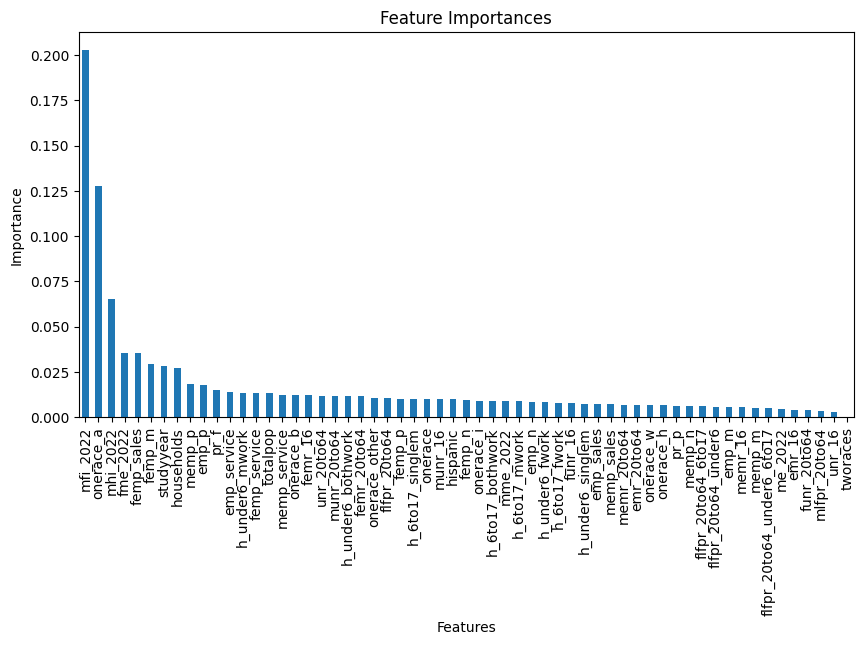

In [10]:
# Selecting 8 number of features

from xgboost import XGBRegressor
from sklearn.feature_selection import RFE
import pandas as pd
import matplotlib.pyplot as plt

xgb_model = XGBRegressor(n_estimators=100,learning_rate=0.01)
xgb_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(xgb_model.feature_importances_, index=num_features)

# Sort and select top 10 features
selected_features = feature_importances.nlargest().index.tolist()

# Print selected features
print("Selected Features:", selected_features)

# Plot feature importances
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), title="Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.show()


In [11]:
feature_importances

studyyear                    0.028337
emr_16                       0.004172
femr_16                      0.011978
memr_16                      0.005308
emr_20to64                   0.006805
femr_20to64                  0.011652
memr_20to64                  0.006913
unr_16                       0.003062
funr_16                      0.007600
munr_16                      0.009783
unr_20to64                   0.011795
funr_20to64                  0.004164
munr_20to64                  0.011752
flfpr_20to64                 0.010398
flfpr_20to64_under6          0.005615
flfpr_20to64_6to17           0.005868
flfpr_20to64_under6_6to17    0.004872
mlfpr_20to64                 0.003624
pr_f                         0.015030
pr_p                         0.006318
mfi_2022                     0.202675
mhi_2022                     0.065100
me_2022                      0.004444
fme_2022                     0.035588
mme_2022                     0.008778
totalpop                     0.013350
onerace     

In [74]:
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, RegressorMixin

# Create a compatible wrapper
class SklearnXGBWrapper(XGBRegressor, BaseEstimator, RegressorMixin):
    def __sklearn_tags__(self):
        return {
            "non_deterministic": False,
            "requires_positive_X": False,
            "requires_positive_y": False,
            "multioutput": False,
            "allow_nan": True,
            "requires_fit": True,
        }



from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# Use the wrapper
xgb_model = SklearnXGBWrapper()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Use regression scoring
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score (Negative MSE):", grid_search.best_score_)


c:\Users\Gaurja Newatia\Documents\GitHub\Childcare-Price-Prediction\venv\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SklearnXGBWrapper or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [76]:
print(xgb.__version__)

2.1.3


In [81]:
import sklearn
print(sklearn.__version__)

1.6.0


In [57]:
selected_features

['mfi_2022',
 'onerace_a',
 'mhi_2022',
 'femp_sales',
 'studyyear',
 'fme_2022',
 'households',
 'munr_20to64',
 'emp_p',
 'totalpop']